In [21]:
!pip install prophet

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

In [23]:
path = kagglehub.dataset_download('pratyushpuri/grocery-store-sales-dataset-in-2025-1900-record')

csv_path  =os.path.join(path, 'grocery_chain_data.csv')

df = pd.read_csv(csv_path)
df.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2.0,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1.0,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4.0,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3.0,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5.0,8.66,43.30,1.50,41.80,22


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   float64
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 170.3+ KB


In [25]:
df.describe(include='all')

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
count,1980.000000,1955,1980,1980,1980,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000
unique,NaN,9,689,11,18,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,City Fresh Store,2023-10-18,Beverages,Chicken Breast,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,235,11,195,131,NaN,NaN,NaN,NaN,NaN,NaN
mean,5542.958081,NaN,NaN,NaN,NaN,2.968182,15.488045,45.902576,4.469591,41.432985,255.147980
std,2575.771856,NaN,NaN,NaN,NaN,1.419028,8.400823,35.018599,4.962001,32.593328,146.009333
min,1006.000000,NaN,NaN,NaN,NaN,1.000000,0.990000,1.010000,0.000000,-3.430000,0.000000
25%,3271.500000,NaN,NaN,NaN,NaN,2.000000,8.240000,18.000000,1.240000,15.800000,128.000000
50%,5582.500000,NaN,NaN,NaN,NaN,3.000000,15.190000,37.130000,3.045000,32.820000,265.500000
75%,7791.750000,NaN,NaN,NaN,NaN,4.000000,22.862500,67.930000,5.402500,60.800000,378.000000


In [26]:
missing_values = df.isnull().sum()
print(missing_values[missing_values >0])

df['store_name'] = df['store_name'].fillna('Unknown Store')

missing_values = df.isnull().sum()
missing_values[missing_values >0]

store_name    25
dtype: int64


Series([], dtype: int64)

In [27]:
df.duplicated().sum()

np.int64(0)

In [29]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
dfharian = df.groupby('transaction_date')['quantity'].sum().reset_index()
dfnew = dfharian.rename(columns={'transaction_date': 'ds', 'quantity' : 'y'})
dfnew.head()

,ds,y
0,2023-08-07,2.0
1,2023-08-08,15.0
2,2023-08-11,6.0
3,2023-08-12,11.0
4,2023-08-13,9.0


In [32]:
model = Prophet()
model.fit(dfnew)
print('Selesai Dilatih')

20:14:26 - cmdstanpy - INFO - Chain [1] start processing
20:14:26 - cmdstanpy - INFO - Chain [1] done processing


Selesai Dilatih


            ds      yhat  yhat_lower  yhat_upper
714 2025-08-31  8.069474    1.802065   14.472628
715 2025-09-01  8.131122    1.679863   14.216416
716 2025-09-02  8.433902    1.614278   15.426507
717 2025-09-03  8.539771    1.653969   14.536263
718 2025-09-04  8.299225    2.274256   14.881901


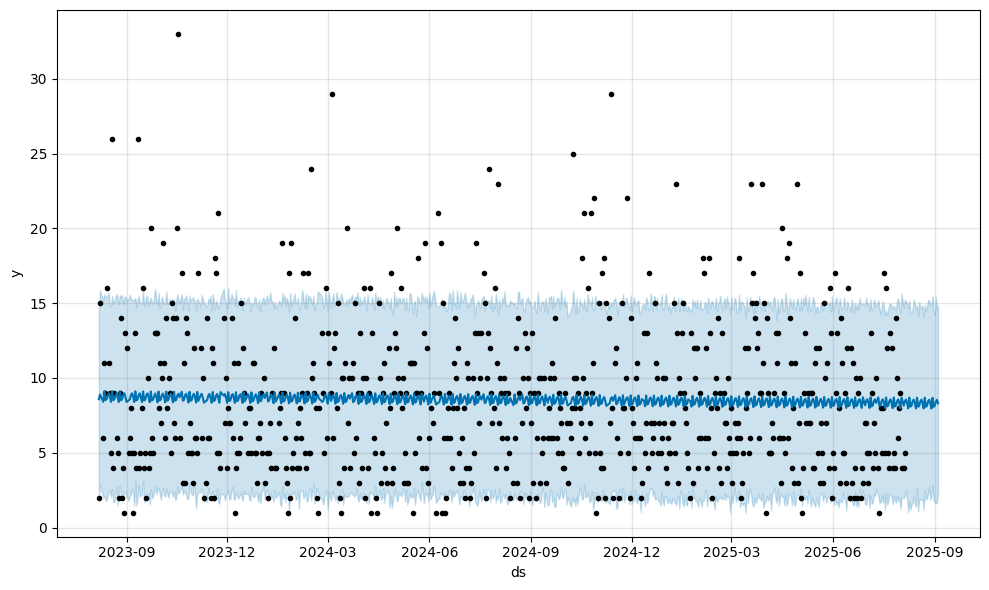

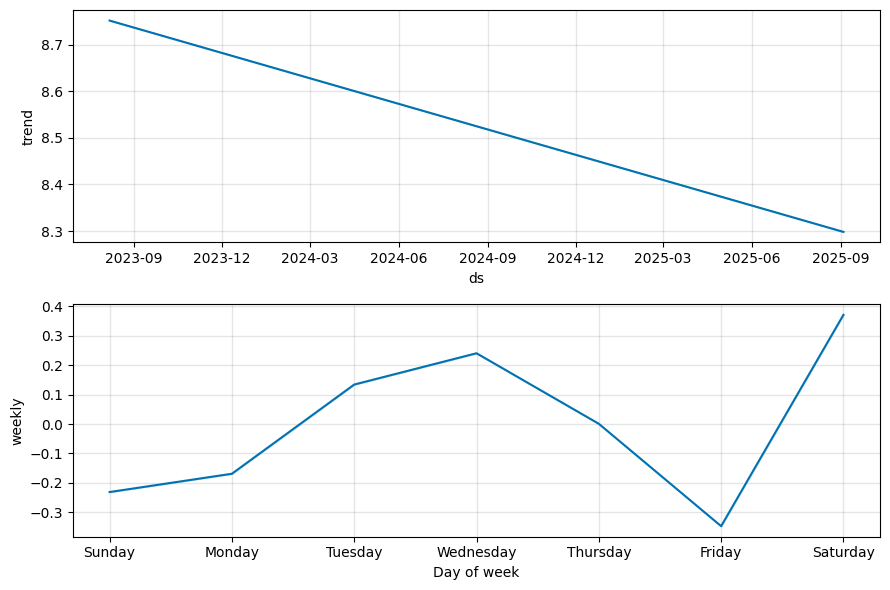

In [33]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

In [40]:
df_cv = cross_validation(model, initial ='365 days', period='180 days', horizon='30 days')

df_pm = performance_metrics(df_cv)

print(df_pm['mae'].mean())
print(df_pm['rmse'].mean())

df_pm.head(10)

  0%|          | 0/2 [00:00<?, ?it/s]

20:59:27 - cmdstanpy - INFO - Chain [1] start processing
20:59:27 - cmdstanpy - INFO - Chain [1] done processing
20:59:27 - cmdstanpy - INFO - Chain [1] start processing
20:59:27 - cmdstanpy - INFO - Chain [1] done processing


3.9702502710370564
4.635777190861978


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,56.936930,7.545656,5.811404,0.606556,0.670572,0.568209,0.7
1,4 days,53.719280,7.329344,5.436255,0.466596,0.656061,0.488789,0.8
2,5 days,57.549629,7.586147,5.959972,0.716859,0.656061,0.601697,0.8
3,6 days,14.526381,3.811349,3.503144,0.713334,0.323570,0.485498,1.0
4,7 days,20.785903,4.559156,3.826465,2.063749,1.200344,0.691288,0.8
5,8 days,16.995984,4.122619,3.108182,1.662244,0.343362,0.504099,0.8
6,9 days,20.687313,4.548331,3.760803,1.034275,0.443442,0.470771,0.7
7,10 days,13.790433,3.713547,2.870833,0.311105,0.121544,0.305879,0.8
8,11 days,21.581626,4.645603,3.283233,0.279587,0.121544,0.308936,0.7
9,12 days,17.836957,4.223382,2.922733,0.297930,0.157701,0.301976,0.8
